In [61]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [62]:
# Load dataset
from google.colab import files
uploaded = files.upload()

Jamb = pd.read_csv('/content/New Jamb Dataset.csv')
print(df.shape)
Jamb.head()

Saving New Jamb Dataset.csv to New Jamb Dataset (2).csv
(450, 24)


,jamb_attempts_count,jamb_year_most_recent,jamb_score_most_recent,school_type,school_location,gender,age_when_took_jamb,study_hours_per_day,study_resources,attended_extra_tutorials,...,access_to_computer_smartphone,household_dependents,internet_reliability,access_to_textbooks,electricity_consistency,quality_of_instruction,familiar_with_cbt,arrived_early_exam_center,biggest_challenge,advice_to_future_candidate
0,4,2025,219,Private,Semi-Urban,Male,18-20 years,3-4 hours,"Past questions, Online tutorials/videos",No,...,Yes,NaN,Very Reliable,Most of them,Daily,Excellent,Yes,"Yes, significantly early",Sometimes poor network connection,Use every opportunity of your time to study
1,1,2022,204,Private,Semi-Urban,Female,21-23 years,1-2 hours,Past questions,No,...,Yes,1-2 dependents,Moderately Reliable,Most of them,Daily,Good,Yes,"Yes, a little early",Having to combine work and study,A more precise syllabus
2,2,2022,203,Public/Government/Government,Semi-Urban,Female,18-20 years,3-4 hours,"Past questions, Textbooks",No,...,No,3-5 dependents,Slightly Reliable,Very few,A few days a week,Average,No,"Yes, significantly early",Being consistent in the reading,Read and dont depend on past questions only
3,1,2022,200,Private,Urban,Female,18-20 years,1-2 hours,"Past questions, Textbooks, Physical tutorials/...",Yes,...,Yes,1-2 dependents,Very Reliable,"Yes, all",Most days,Excellent,Yes,"Yes, a little early",Time,Be well prepared pray
4,1,2022,283,Public/Government/Government,Urban,Male,15-17 years,4+ hours,"Past questions, Textbooks, Physical tutorials/...",Yes,...,Yes,6-8 dependents,Moderately Reliable,Most of them,Most days,Excellent,Yes,"Yes, a little early",Literature,"Work Hard, Be smart"


In [63]:
# Checking the data information
Jamb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   jamb_attempts_count            900 non-null    int64 
 1   jamb_year_most_recent          900 non-null    int64 
 2   jamb_score_most_recent         900 non-null    int64 
 3   school_type                    900 non-null    object
 4   school_location                900 non-null    object
 5   gender                         900 non-null    object
 6   age_when_took_jamb             900 non-null    object
 7   study_hours_per_day            900 non-null    object
 8   study_resources                900 non-null    object
 9   attended_extra_tutorials       900 non-null    object
 10  consistent_study_schedule      900 non-null    object
 11  study_plan_adherence           900 non-null    object
 12  guardian_education_level       774 non-null    object
 13  acces

In [64]:
# Check missing values
print(Jamb.isnull().sum())
print("\n")

jamb_attempts_count                0
jamb_year_most_recent              0
jamb_score_most_recent             0
school_type                        0
school_location                    0
gender                             0
age_when_took_jamb                 0
study_hours_per_day                0
study_resources                    0
attended_extra_tutorials           0
consistent_study_schedule          0
study_plan_adherence               0
guardian_education_level         126
access_to_computer_smartphone      0
household_dependents              26
internet_reliability               0
access_to_textbooks                0
electricity_consistency            0
quality_of_instruction             0
familiar_with_cbt                  0
arrived_early_exam_center          0
biggest_challenge                  2
advice_to_future_candidate         0
dtype: int64




In [65]:
# Strip whitespace from all text columns first
Jamb = Jamb.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

In [66]:
# Check score distribution
Jamb['jamb_score_most_recent'].describe()

,jamb_score_most_recent
count,900.000000
mean,184.651111
std,48.859113
min,81.000000
25%,149.000000
50%,182.500000
75%,219.000000
max,355.000000


score_category
At Risk     384
Critical    298
On Track    218
Name: count, dtype: int64


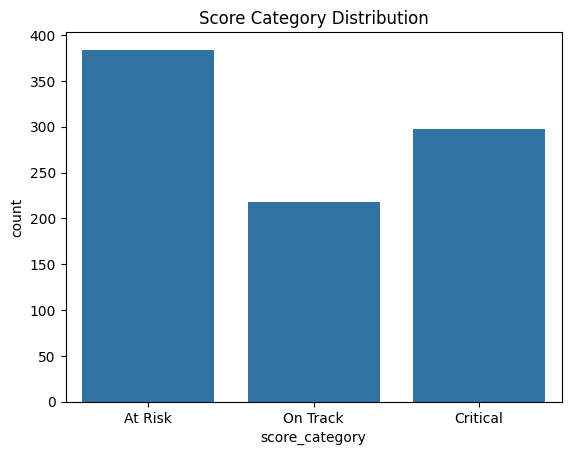

In [67]:
def categorize_score(score):
    if score >= 220:
        return 'On Track'
    elif score >= 160:
        return 'At Risk'
    else:
        return 'Critical'

Jamb['score_category'] = Jamb['jamb_score_most_recent'].apply(categorize_score)

# Check category distribution
print(Jamb['score_category'].value_counts())
sns.countplot(x='score_category', data=Jamb)
plt.title('Score Category Distribution')
plt.show()

Findings: High Performer has only 12 rows.  which was insufficient for the model to learn from.
Merging it into On Track (220 and above) produces a cleaner and more balanced three-class target variable.

In [68]:
# Map age to numeric midpoint
age_map = {
    '15-17 years': 16,
    '18-20 years': 19,
    '21-23 years': 22,
    '24-25 years': 24
}
Jamb['age_when_took_jamb'] = Jamb['age_when_took_jamb'].map(age_map)

# Map study hours to numeric midpoint
study_hours_map = {
    '<1 hour': 0.5,
    '1-2 hours': 1.5,
    '2-3 hours': 2.5,
    '3-4 hours': 3.5,
    '4+ hours': 5.0
}
Jamb['study_hours_per_day'] = Jamb['study_hours_per_day'].map(study_hours_map)

# Map household dependents to numeric midpoint
dependents_map = {
    '1-2 dependents': 1.5,
    '3-5 dependents': 4.0,
    '6-8 dependents': 7.0,
    '9+ dependents': 9.0
}
Jamb['household_dependents'] = Jamb['household_dependents'].map(dependents_map)

In [69]:
# Handle missing values
# guardian_education_level is categorical, fill with mode (most common value)
Jamb['guardian_education_level'].fillna(Jamb['guardian_education_level'].mode()[0], inplace=True)

# household_dependents is now numeric, fill with median to avoid skew from "9+ dependents"
Jamb['household_dependents'].fillna(Jamb['household_dependents'].median(), inplace=True)

# biggest_challenge is free text with 1 missing value, fill with Unknown
Jamb['biggest_challenge'].fillna('Unknown', inplace=True)

# Confirm no missing values remain
print(Jamb.isnull().sum())

jamb_attempts_count              0
jamb_year_most_recent            0
jamb_score_most_recent           0
school_type                      0
school_location                  0
gender                           0
age_when_took_jamb               0
study_hours_per_day              0
study_resources                  0
attended_extra_tutorials         0
consistent_study_schedule        0
study_plan_adherence             0
guardian_education_level         0
access_to_computer_smartphone    0
household_dependents             0
internet_reliability             0
access_to_textbooks              0
electricity_consistency          0
quality_of_instruction           0
familiar_with_cbt                0
arrived_early_exam_center        0
biggest_challenge                0
advice_to_future_candidate       0
score_category                   0
dtype: int64


 After cleaning and processing, all 23 columns show zero missing values across all 900 rows. This confirms that the missing value treatment applied earlier using mode for guardian_education_level, median for household_dependents, and "Unknown" for biggest_challenge worked correctly on the expanded dataset. The data is fully clean and ready for encoding and model training.

In [70]:
Jamb.head()

,jamb_attempts_count,jamb_year_most_recent,jamb_score_most_recent,school_type,school_location,gender,age_when_took_jamb,study_hours_per_day,study_resources,attended_extra_tutorials,...,household_dependents,internet_reliability,access_to_textbooks,electricity_consistency,quality_of_instruction,familiar_with_cbt,arrived_early_exam_center,biggest_challenge,advice_to_future_candidate,score_category
0,4,2025,219,Private,Semi-Urban,Male,19,3.5,"Past questions, Online tutorials/videos",No,...,4.0,Very Reliable,Most of them,Daily,Excellent,Yes,"Yes, significantly early",Sometimes poor network connection,Use every opportunity of your time to study,At Risk
1,1,2022,204,Private,Semi-Urban,Female,22,1.5,Past questions,No,...,1.5,Moderately Reliable,Most of them,Daily,Good,Yes,"Yes, a little early",Having to combine work and study,A more precise syllabus,At Risk
2,2,2022,203,Public/Government/Government,Semi-Urban,Female,19,3.5,"Past questions, Textbooks",No,...,4.0,Slightly Reliable,Very few,A few days a week,Average,No,"Yes, significantly early",Being consistent in the reading,Read and dont depend on past questions only,At Risk
3,1,2022,200,Private,Urban,Female,19,1.5,"Past questions, Textbooks, Physical tutorials/...",Yes,...,1.5,Very Reliable,"Yes, all",Most days,Excellent,Yes,"Yes, a little early",Time,Be well prepared pray,At Risk
4,1,2022,283,Public/Government/Government,Urban,Male,16,5.0,"Past questions, Textbooks, Physical tutorials/...",Yes,...,7.0,Moderately Reliable,Most of them,Most days,Excellent,Yes,"Yes, a little early",Literature,"Work Hard, Be smart",On Track


# Exploratroy Data Analysis

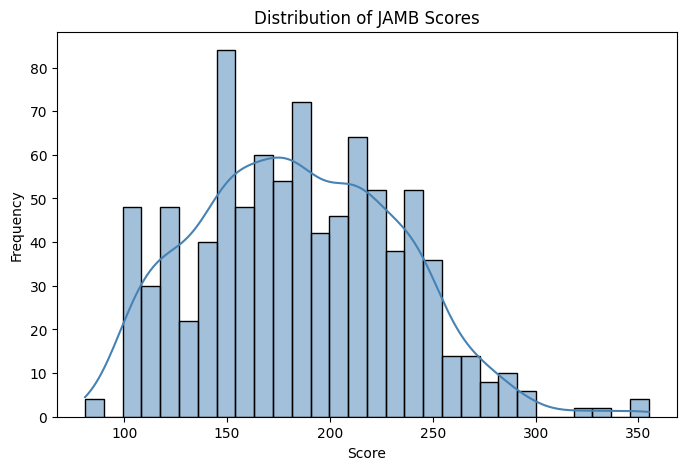

In [71]:
# Score distribution
plt.figure(figsize=(8,5))
sns.histplot(Jamb['jamb_score_most_recent'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of JAMB Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

# Distribution of JAMB Scores
The histogram shows that JAMB scores in this dataset follow a roughly bell-shaped distribution with a slight right skew. The highest frequency of students scored between 140 and 200, with the peak around 150. This aligns with the mean score of 184.65 computed earlier. Very few students scored above 280, confirming that high performance is rare in this dataset. The KDE curve confirms the distribution is concentrated in the At Risk and Critical bands, meaning the majority of students in this dataset are struggling with JAMB performance.

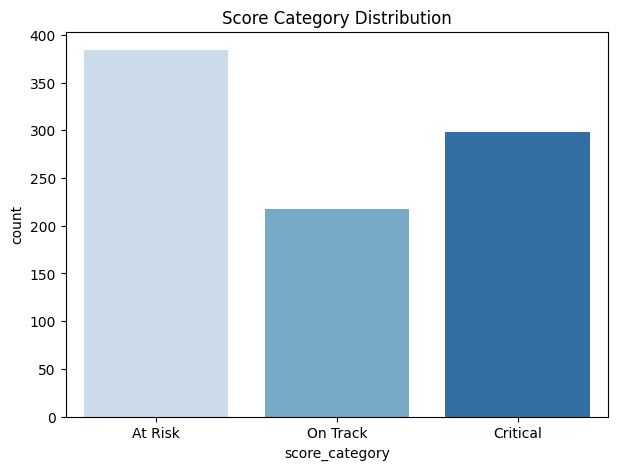

In [72]:
# Score category count
plt.figure(figsize=(7,5))
sns.countplot(x='score_category', data=Jamb, palette='Blues')
plt.title('Score Category Distribution')
plt.show()

# Score Category Distribution
The bar chart shows that At Risk is the largest category with 384 students, followed by Critical with 298 students, and On Track with 218 students. This confirms a class imbalance in the dataset, with over 75% of students falling below the On Track threshold of 220. This pattern reflects the real academic challenge Nigerian students face with JAMB and reinforces why the model needs to correctly identify At Risk and Critical students for early intervention.

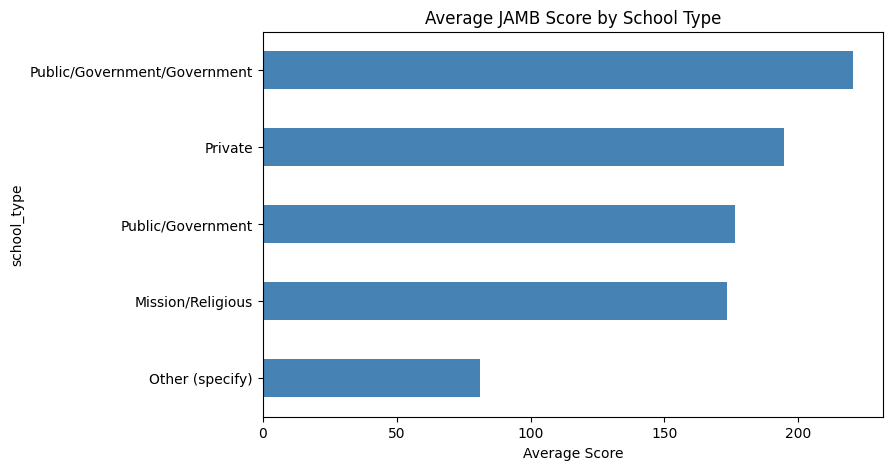

In [73]:
# Average score by school type
plt.figure(figsize=(8,5))
Jamb.groupby('school_type')['jamb_score_most_recent'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average JAMB Score by School Type')
plt.xlabel('Average Score')
plt.show()

# Average JAMB Score by School Type

Students from Public/Government/Government schools recorded the highest average JAMB score at approximately 220, which falls in the On Track band. Private school students followed with an average of around 195. Public/Government and Mission/Religious schools both averaged around 178, placing them in the At Risk band. Students categorised under Other recorded the lowest average of approximately 80, falling deep in the Critical band. This suggests that school type has some relationship with performance, though the Other category likely represents a very small group with unreliable data.

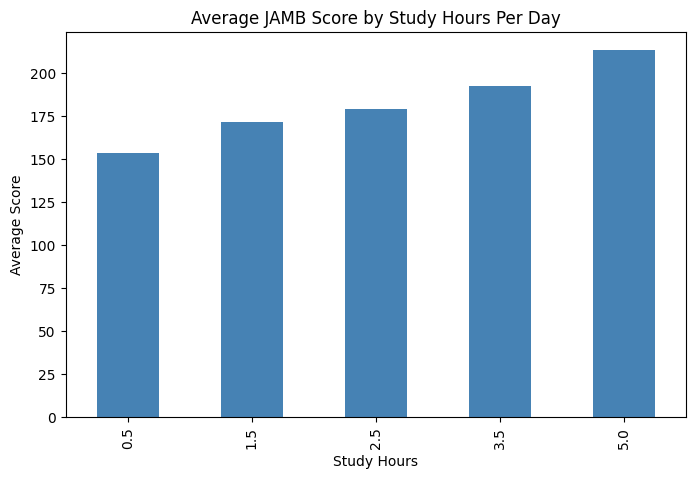

In [74]:
# Average score by study hours
plt.figure(figsize=(8,5))
Jamb.groupby('study_hours_per_day')['jamb_score_most_recent'].mean().sort_values().plot(kind='bar', color='steelblue')
plt.title('Average JAMB Score by Study Hours Per Day')
plt.xlabel('Study Hours')
plt.ylabel('Average Score')
plt.show()

#Average JAMB Score by Study Hours Per Day

The bar chart shows a clear and consistent upward trend. Students who studied less than 1 hour per day averaged around 155, placing them in the Critical band. Those who studied 1 to 2 hours averaged around 170, still in the Critical band. Students studying 2 to 3 hours averaged around 178, entering the At Risk band. Those studying 3 to 4 hours averaged around 193, and students who studied more than 4 hours per day averaged around 212, the highest of all groups and approaching the On Track threshold. This confirms that study hours per day is one of the strongest predictors of JAMB performance in this dataset.

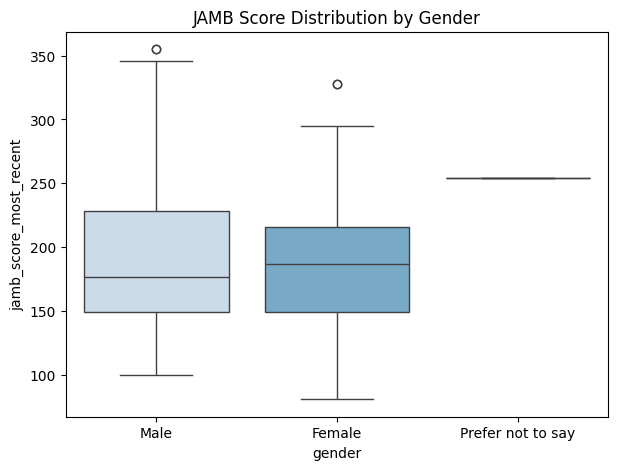

In [75]:
# Score by gender
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='jamb_score_most_recent', data=Jamb, palette='Blues')
plt.title('JAMB Score Distribution by Gender')
plt.show()


# JAMB Score Distribution by Gender

The boxplot shows that male and female students have similar median scores of approximately 183 and 188 respectively, both falling within the At Risk band. Female students show a slightly tighter score distribution, while male students have a wider spread. The Prefer not to say group shows only a single data point at approximately 255, which is too small a sample to draw any meaningful conclusion. Overall, gender does not appear to be a strong differentiator of JAMB performance in this dataset.

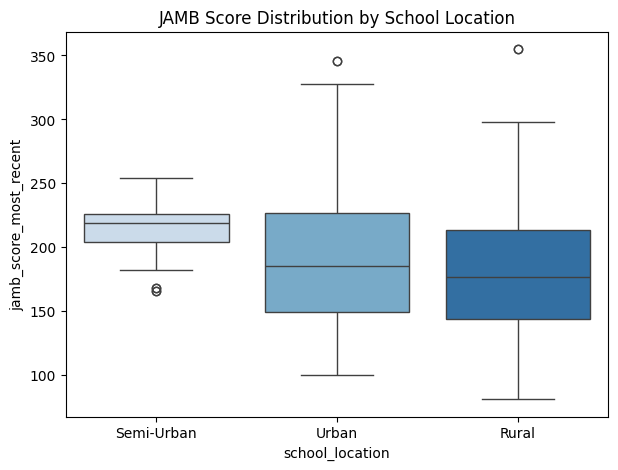

In [76]:
# Score by school location
plt.figure(figsize=(7,5))
sns.boxplot(x='school_location', y='jamb_score_most_recent', data=Jamb, palette='Blues')
plt.title('JAMB Score Distribution by School Location')
plt.show()

#JAMB Score Distribution by School Location

Semi-Urban students recorded the highest median score at approximately 215, placing them just below the On Track threshold. Urban students had a median of approximately 183, falling in the At Risk band. Rural students had the lowest median at approximately 180, also in the At Risk band. Semi-Urban students also show the narrowest score spread, suggesting more consistent performance. This finding is somewhat surprising as Urban students might be expected to outperform Semi-Urban students, but it may reflect differences in school quality or competition within urban areas.

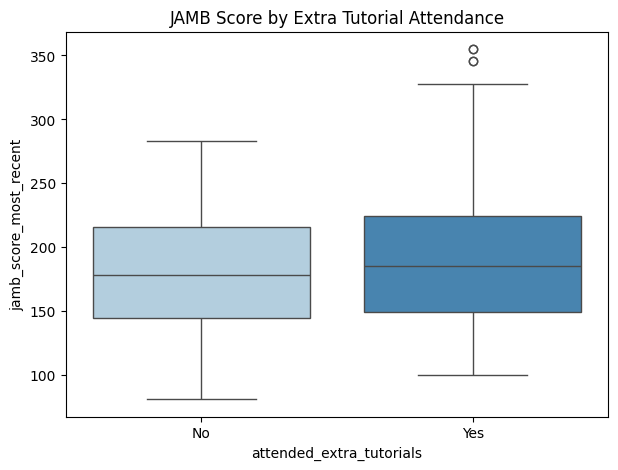

In [77]:
# Score by extra tutorials
plt.figure(figsize=(7,5))
sns.boxplot(x='attended_extra_tutorials', y='jamb_score_most_recent', data=Jamb, palette='Blues')
plt.title('JAMB Score by Extra Tutorial Attendance')
plt.show()

# JAMB Score by Extra Tutorial Attendance

The boxplot shows that students who attended extra tutorials and those who did not have very similar median scores of approximately 183 and 185 respectively. The interquartile ranges also overlap heavily. This suggests that simply attending extra tutorials does not guarantee a higher JAMB score. The quality of tutorials, consistency of attendance, and personal study habits likely matter more than attendance alone. This is an important finding for students planning their JAMB preparation.

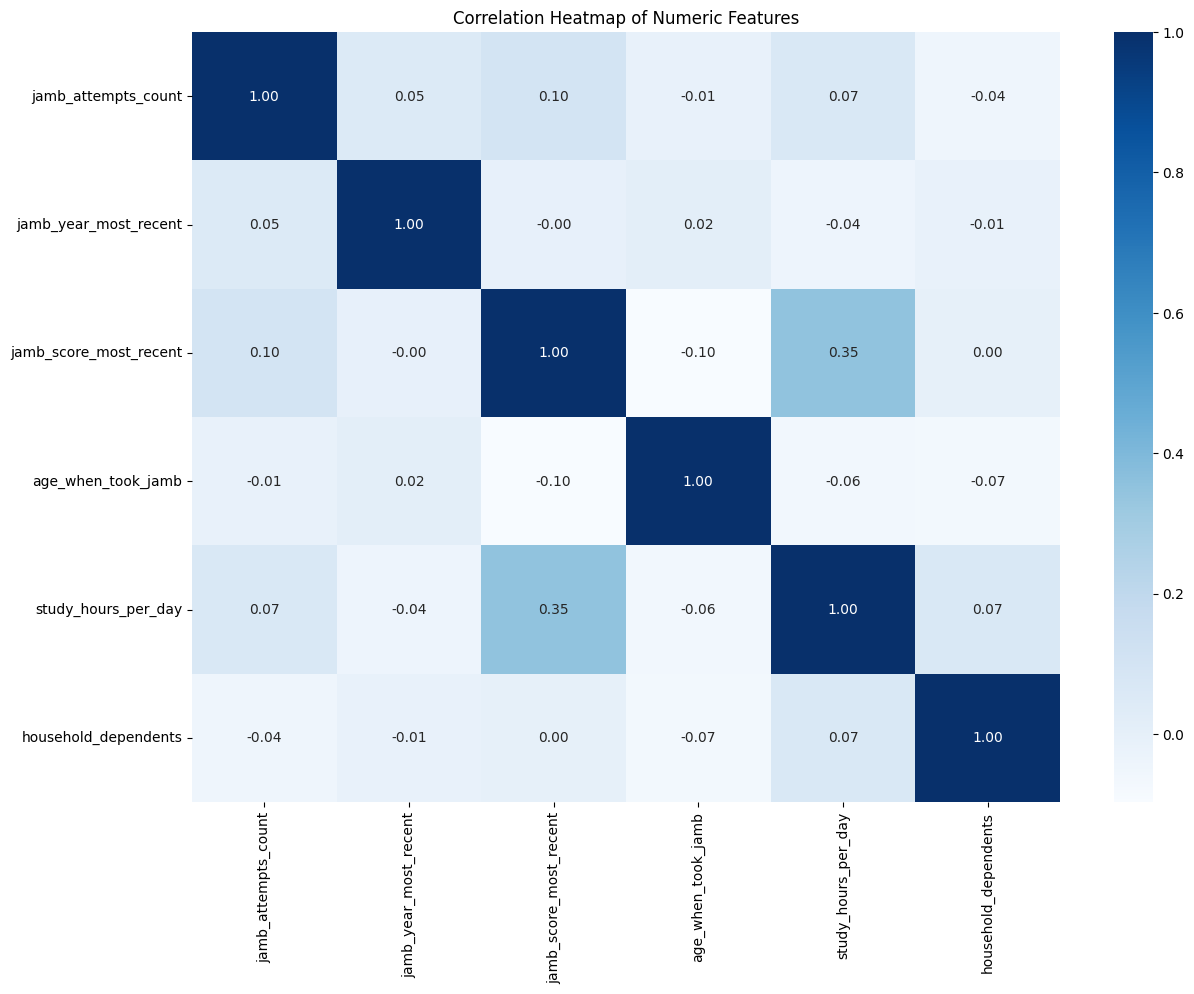

In [78]:
# Correlation heatmap
plt.figure(figsize=(14,10))
numeric_df = Jamb.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Correlation Heatmap of Numeric Features

The heatmap reveals that study_hours_per_day has the strongest positive correlation with jamb_score_most_recent at 0.35. This confirms the finding from the bar chart that more study hours consistently link to higher scores. The correlation between age_when_took_jamb and jamb_score_most_recent is slightly negative at -0.10, suggesting that older students tend to score marginally lower, though the relationship is weak. jamb_attempts_count shows a weak positive correlation of 0.10 with the score, meaning repeated attempts have minimal impact on improvement. household_dependents and jamb_year_most_recent show near zero correlation with the score, confirming they contribute little predictive value on their own. Overall the correlations are moderate, which is expected in survey-based datasets where human behaviour is complex and not fully captured by numbers alone.

In [79]:
# Drop columns not useful for prediction
Jamb = Jamb.drop(columns=[
    'jamb_score_most_recent',
    'advice_to_future_candidate',
    'biggest_challenge',
    'jamb_year_most_recent'
])
# Confirm remaining columns
print(Jamb.shape)
Jamb.columns.tolist()

(900, 20)


['jamb_attempts_count',
 'school_type',
 'school_location',
 'gender',
 'age_when_took_jamb',
 'study_hours_per_day',
 'study_resources',
 'attended_extra_tutorials',
 'consistent_study_schedule',
 'study_plan_adherence',
 'guardian_education_level',
 'access_to_computer_smartphone',
 'household_dependents',
 'internet_reliability',
 'access_to_textbooks',
 'electricity_consistency',
 'quality_of_instruction',
 'familiar_with_cbt',
 'arrived_early_exam_center',
 'score_category']

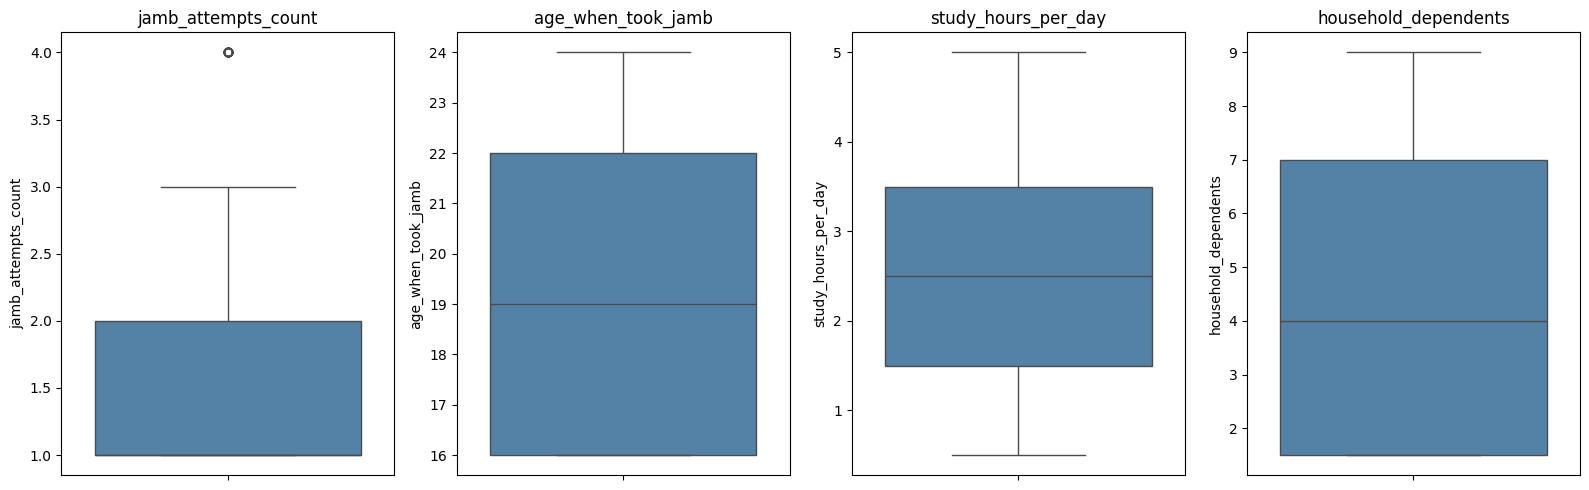

In [80]:
#Checking for Outlier
numeric_cols = ['jamb_attempts_count', 'age_when_took_jamb',
                'study_hours_per_day', 'household_dependents']

# Boxplot to visualise outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=Jamb[col], ax=ax, color='steelblue')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [81]:
# IQR method to count outliers
print("Outlier counts per column:\n")
for col in numeric_cols:
    Q1 = Jamb[col].quantile(0.25)
    Q3 = Jamb[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = Jamb[(Jamb[col] < lower) | (Jamb[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")

Outlier counts per column:

jamb_attempts_count: 30 outliers | Lower bound: -0.50 | Upper bound: 3.50
age_when_took_jamb: 0 outliers | Lower bound: 7.00 | Upper bound: 31.00
study_hours_per_day: 0 outliers | Lower bound: -1.50 | Upper bound: 6.50
household_dependents: 0 outliers | Lower bound: -6.75 | Upper bound: 15.25


The dataset now has 900 rows and 20 columns after dropping irrelevant columns. All cleaning, mapping, and encoding steps applied to the original dataset have been successfully replicated on the expanded version. The data is ready for model training.

In [82]:
# Check remaining object columns
cat_cols = Jamb.select_dtypes(include='object').columns.tolist()
print(cat_cols)

# Check unique values for each
for col in cat_cols:
    print(f"\n{col}:")
    print(Jamb[col].unique())

['school_type', 'school_location', 'gender', 'study_resources', 'attended_extra_tutorials', 'consistent_study_schedule', 'study_plan_adherence', 'guardian_education_level', 'access_to_computer_smartphone', 'internet_reliability', 'access_to_textbooks', 'electricity_consistency', 'quality_of_instruction', 'familiar_with_cbt', 'arrived_early_exam_center', 'score_category']

school_type:
['Private' 'Public/Government/Government' 'Mission/Religious'
 'Other (specify)' 'Public/Government']

school_location:
['Semi-Urban' 'Urban' 'Rural']

gender:
['Male' 'Female' 'Prefer not to say']

study_resources:
['Past questions, Online tutorials/videos' 'Past questions'
 'Past questions, Textbooks'
 'Past questions, Textbooks, Physical tutorials/coaching centers'
 'Past questions, Textbooks, Physical tutorials/coaching centers, Study groups'
 'Past questions, Online tutorials/videos, Physical tutorials/coaching centers, Private lessons'
 'Past questions, Textbooks, Online tutorials/videos' 'Textbooks

In [83]:
# Fix school_type duplicate
Jamb['school_type'] = Jamb['school_type'].replace(
    'Public/Government/Government', 'Public/Government')

# Drop arrived_early_exam_center, it has no variation
Jamb = Jamb.drop(columns=['arrived_early_exam_center'])

In [84]:
# Multi-label encode study_resources
resources = ['Past questions', 'Textbooks', 'Online tutorials/videos',
             'Physical tutorials/coaching centers', 'Private lessons',
             'Study groups']

for resource in resources:
    Jamb[f'resource_{resource.lower().replace(" ", "_").replace("/", "_")}'] = \
        Jamb['study_resources'].apply(lambda x: 1 if resource in str(x) else 0)

# Drop original study_resources column
Jamb = Jamb.drop(columns=['study_resources'])

In [85]:
# Ordinal encode ordered categories
ordinal_maps = {
    'study_plan_adherence': {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'internet_reliability': {'No Access': 0, 'Slightly Reliable': 1, 'Moderately Reliable': 2, 'Very Reliable': 3},
    'access_to_textbooks': {'No': 0, 'Very few': 1, 'Some of them': 2, 'Most of them': 3, 'Yes, all': 4},
    'electricity_consistency': {'Never': 0, 'Rarely': 1, 'A few days a week': 2, 'Most days': 3, 'Daily': 4},
    'quality_of_instruction': {'Very Poor': 0, 'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4},
    'guardian_education_level': {'Primary': 0, 'Secondary': 1, 'Tertiary': 2},
    'consistent_study_schedule': {'No': 0, 'Sometimes': 1, 'Yes': 2}
}

for col, mapping in ordinal_maps.items():
    Jamb[col] = Jamb[col].map(mapping)

In [86]:
# Label encode remaining binary and nominal columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

binary_cols = ['school_type', 'school_location', 'gender',
               'attended_extra_tutorials', 'access_to_computer_smartphone',
               'familiar_with_cbt']

for col in binary_cols:
    Jamb[col] = le.fit_transform(Jamb[col])

In [87]:
# Encode target variable
target_map = {'Critical': 0, 'At Risk': 1, 'On Track': 2}
Jamb['score_category'] = Jamb['score_category'].map(target_map)

In [88]:
# Confirm final shape and no missing values
print(Jamb.shape)
print(Jamb.isnull().sum())
print(Jamb.head())

(900, 24)
jamb_attempts_count                             0
school_type                                     0
school_location                                 0
gender                                          0
age_when_took_jamb                              0
study_hours_per_day                             0
attended_extra_tutorials                        0
consistent_study_schedule                       0
study_plan_adherence                            0
guardian_education_level                        0
access_to_computer_smartphone                   0
household_dependents                            0
internet_reliability                            0
access_to_textbooks                             0
electricity_consistency                         0
quality_of_instruction                          0
familiar_with_cbt                               0
score_category                                  0
resource_past_questions                         0
resource_textbooks                      

#Model Ready

All categorical columns are now encoded as integers. Ordinal columns like study_plan_adherence, internet_reliability, electricity_consistency, and quality_of_instruction are encoded on a scale that preserves their natural order.
Binary columns like attended_extra_tutorials, familiar_with_cbt, and access_to_computer_smartphone are encoded as 0 and 1. The study_resources column has been split into six binary feature columns covering past questions, textbooks, online tutorials, physical tutorials, private lessons, and study groups. The target variable score_category is encoded as 0 for Critical, 1 for At Risk, and 2 for On Track. The dataset is fully ready for model training.

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
# Separate features and target
X = Jamb.drop(columns=['score_category'])
y = Jamb['score_category']

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTesting class distribution:\n{y_test.value_counts()}")

Training rows: 720
Testing rows: 180

Training class distribution:
score_category
1    307
0    238
2    175
Name: count, dtype: int64

Testing class distribution:
score_category
1    77
0    60
2    43
Name: count, dtype: int64


#Building the Machine Learning Model

In [91]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.2%}")
print(classification_report(y_test, rf_preds,
      target_names=['Critical','At Risk', 'On Track']))

RANDOM FOREST RESULTS
Accuracy: 90.00%
              precision    recall  f1-score   support

    Critical       0.89      0.83      0.86        60
     At Risk       0.86      0.97      0.91        77
    On Track       1.00      0.86      0.93        43

    accuracy                           0.90       180
   macro avg       0.92      0.89      0.90       180
weighted avg       0.91      0.90      0.90       180



In [92]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBOOST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.2%}")
print(classification_report(y_test, xgb_preds,
      target_names=['Critical', 'At Risk', 'On Track']))

XGBOOST RESULTS
Accuracy: 88.89%
              precision    recall  f1-score   support

    Critical       0.86      0.83      0.85        60
     At Risk       0.86      0.92      0.89        77
    On Track       1.00      0.91      0.95        43

    accuracy                           0.89       180
   macro avg       0.91      0.89      0.90       180
weighted avg       0.89      0.89      0.89       180



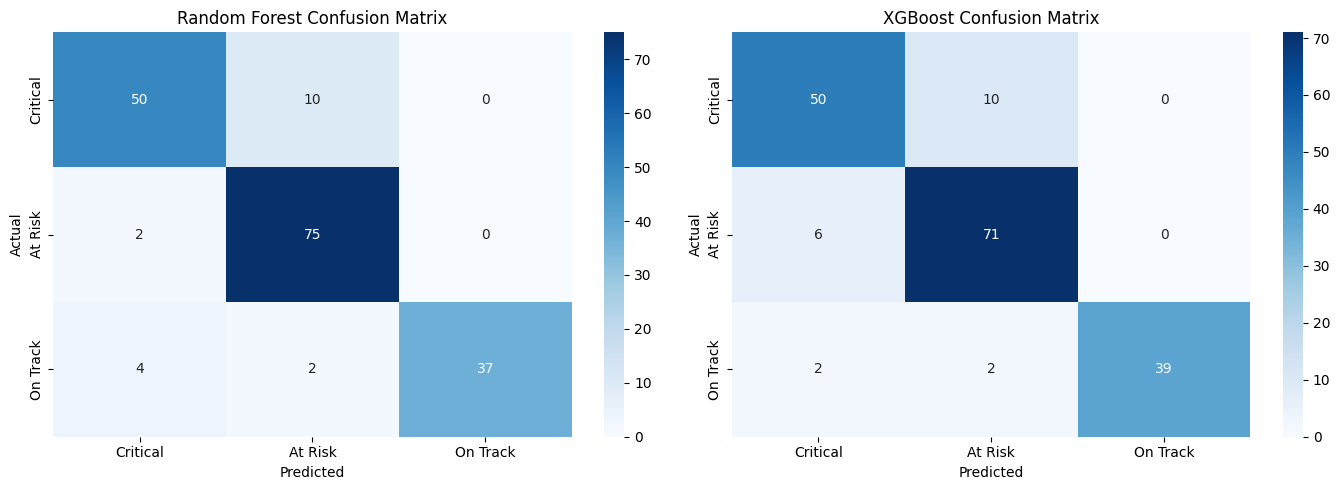

In [93]:
# Plot confusion matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [rf_preds, xgb_preds],
                             ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=['Critical', 'At Risk', 'On Track'],
                yticklabels=['Critical', 'At Risk', 'On Track'],
                cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# FINDINGS

Random Forest achieved 90.00% accuracy, making it the better performing model in this comparison. Looking at the classification report, Critical scored a precision of 0.89 and recall of 0.83, giving an F1-score of 0.86. At Risk scored a precision of 0.86 and recall of 0.97, giving an F1-score of 0.91, making it the best predicted class. On Track scored a perfect precision of 1.00 and recall of 0.86, giving an F1-score of 0.93. The confusion matrix shows that out of 60 Critical students, 50 were correctly identified. Out of 77 At Risk students, 75 were correctly identified. Out of 43 On Track students, 37 were correctly identified.

XGBoost achieved 88.89% accuracy, just 1.11% behind Random Forest. Critical scored an F1-score of 0.85, At Risk scored 0.89, and On Track scored an impressive 0.95. The confusion matrix shows 50 correct Critical predictions, 71 correct At Risk predictions, and 39 correct On Track predictions.
Random Forest is selected as the final model based on its higher overall accuracy of 90% and stronger recall on the At Risk class of 0.97, which is the most critical category for early student intervention. A model that correctly identifies students who need help is more valuable than one that is overly cautious. The macro average F1-score of 0.90 across all three classes confirms that the model performs consistently well and is not biased toward any single category.

In [94]:
import joblib
import json

# Save the Random Forest model
joblib.dump(rf_model, 'jamb_model.pkl')

# Save the feature column names
feature_columns = X.columns.tolist()
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("Model saved successfully")
print(f"Features: {feature_columns}")

Model saved successfully
Features: ['jamb_attempts_count', 'school_type', 'school_location', 'gender', 'age_when_took_jamb', 'study_hours_per_day', 'attended_extra_tutorials', 'consistent_study_schedule', 'study_plan_adherence', 'guardian_education_level', 'access_to_computer_smartphone', 'household_dependents', 'internet_reliability', 'access_to_textbooks', 'electricity_consistency', 'quality_of_instruction', 'familiar_with_cbt', 'resource_past_questions', 'resource_textbooks', 'resource_online_tutorials_videos', 'resource_physical_tutorials_coaching_centers', 'resource_private_lessons', 'resource_study_groups']


In [95]:
from google.colab import files

files.download('jamb_model.pkl')
files.download('feature_columns.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>